In [3]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

In [34]:
# update path if needed
df = pd.read_csv("../data/raw/amazon-reviews-org.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (72500, 9)


,reviewId,reviewDate,mainDepartment,subDepartment,productName,reviewTitle,reviewStar,reviewText,inconsistentStatus
0,R1TWIP923TUPRV,"Reviewed in the United States on August 8, 2021",Beauty and Personal Care,"Foot,Hand & Nail Care","Hard As Hoof Nail Strengthening Cream with Coconut Scent Nail Strengthener, Nail Growth & Conditioning Cuticle Cream Stops Splits, Chips, Cracks & Strengthens Nails, 1 oz",Didn't work,1.0,No change in nails at all.,0
1,R1N5I12682L3YY,"Reviewed in the United States on August 2, 2021",Beauty and Personal Care,"Foot,Hand & Nail Care","Hard As Hoof Nail Strengthening Cream with Coconut Scent Nail Strengthener, Nail Growth & Conditioning Cuticle Cream Stops Splits, Chips, Cracks & Strengthens Nails, 1 oz",Worst nail product I have ever used.,1.0,Garbage! Do not waste your $$$. My nails were worse after using this product for two weeks. Pathetic! Going back to my Vaseline Healthy Hand and and Nails.,1
2,R1S3UGVIPYX6W5,"Reviewed in the United States on July 27, 2021",Beauty and Personal Care,"Foot,Hand & Nail Care","Hard As Hoof Nail Strengthening Cream with Coconut Scent Nail Strengthener, Nail Growth & Conditioning Cuticle Cream Stops Splits, Chips, Cracks & Strengthens Nails, 1 oz",Just didn't work,1.0,Nails are still brittle,1
3,R3RELGNNBTGZ2V,"Reviewed in the United States on July 26, 2021",Beauty and Personal Care,"Foot,Hand & Nail Care","Hard As Hoof Nail Strengthening Cream with Coconut Scent Nail Strengthener, Nail Growth & Conditioning Cuticle Cream Stops Splits, Chips, Cracks & Strengthens Nails, 1 oz",Scum,1.0,Didn’t do any improvement at all.,0
4,RLQ9C5R2KYV67,"Reviewed in the United States on July 24, 2021",Beauty and Personal Care,"Foot,Hand & Nail Care","Hard As Hoof Nail Strengthening Cream with Coconut Scent Nail Strengthener, Nail Growth & Conditioning Cuticle Cream Stops Splits, Chips, Cracks & Strengthens Nails, 1 oz",Okay for cuticles,1.0,"Helped cuticles, didn't do much for my nails. I gave this product a decent time line, two jars, six months. Nails didn't improve.",0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72500 entries, 0 to 72499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   reviewId            72500 non-null  object 
 1   reviewDate          72500 non-null  object 
 2   mainDepartment      72500 non-null  object 
 3   subDepartment       72500 non-null  object 
 4   productName         72500 non-null  object 
 5   reviewTitle         72480 non-null  object 
 6   reviewStar          72500 non-null  float64
 7   reviewText          72493 non-null  object 
 8   inconsistentStatus  72500 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 5.0+ MB


In [36]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values:\n", missing)

Missing values:
 reviewTitle    20
reviewText      7
dtype: int64


Very minimal missing values. Conclusion, drop them.

In [37]:
df = df.dropna(subset=["reviewText"])

In [38]:
df.describe()

,reviewStar,inconsistentStatus
count,72493.000000,72493.000000
mean,2.999890,0.444415
std,1.414233,0.496904
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,1.000000
max,5.000000,1.000000


In [39]:
df["reviewStar"].value_counts().sort_index()

reviewStar
1.0    14500
2.0    14500
3.0    14499
4.0    14496
5.0    14498
Name: count, dtype: int64

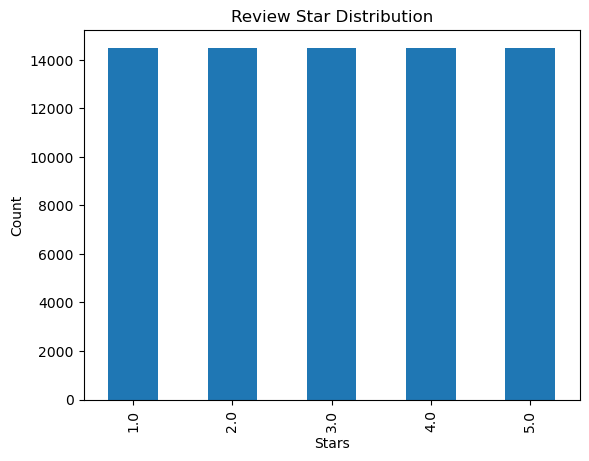

In [40]:
import matplotlib.pyplot as plt

df["reviewStar"].value_counts().sort_index().plot(kind='bar')
plt.title("Review Star Distribution")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

Review Star Distribution appears to be balanced. Theoretically, should show little to no bias to a single class when training with the model.

In [41]:
def create_binary_sentiment(star):
    if star <= 2:
        return 0   # negative
    elif star >= 4:
        return 1   # positive
    else:
        return None  # neutral (3-star)

In [42]:
df["sentiment"] = df["reviewStar"].apply(create_binary_sentiment)

Drop Neutral reviews since focus is on binary classification

In [ ]:
df = df.dropna(subset=["sentiment"])

In [44]:
df["sentiment"].value_counts()

sentiment
0.0    29000
1.0    28994
Name: count, dtype: int64

In [45]:
df["inconsistentStatus"].value_counts()

inconsistentStatus
0    37940
1    20054
Name: count, dtype: int64

Appears to be slight imbalance, but reasonable as it resembles an even split<br>
Dataset appears to be ideal for classification

In [46]:
# Taking a look at a sample of inconsistent reviews
df[df["inconsistentStatus"] == 1][["reviewText", "reviewStar"]].sample(5)

,reviewText,reviewStar
55838,The sizing is off. I require a 34 waist. The medium is DEFINITELY not 34. They are too tight!! They are uncomfortable.I have only started to wear one pair in December (08/2020 purchase)...what a d...,2.0
66072,"When I was ordering it was never clear to me that I was ordering an oversized chair. Actually, I made sure it wasn't, but it was and I had to send it back. Since their product page is not so cle...",4.0
15554,Good for short term but had some issues with tracing,2.0
12355,Easy to use replaces my other one that broke,5.0
17775,"I got this laptop as a simple easy laptop to start animation, but it is incredibly slow and takes like 3 minutes just to start, it has very little storage and it crashed when working on a project ...",1.0


Some seem consistent but there may be more reviews like 41737 ("got what I wanted"; 4.0) or 52828 ("Comfortable and warm!!!"; 1.0) where the review short and vague which may have resulted in a lower star rating. Inconsistencies of this manner may be more akin to a simplified assumption, as there is not enough text to create a strong enough sentiment expression.

In [47]:
df["review_length"] = df["reviewText"].astype(str).apply(len)

df["review_length"].describe()

count    57994.000000
mean       186.452547
std        235.702447
min          1.000000
25%         53.000000
50%        117.000000
75%        234.000000
max       7151.000000
Name: review_length, dtype: float64

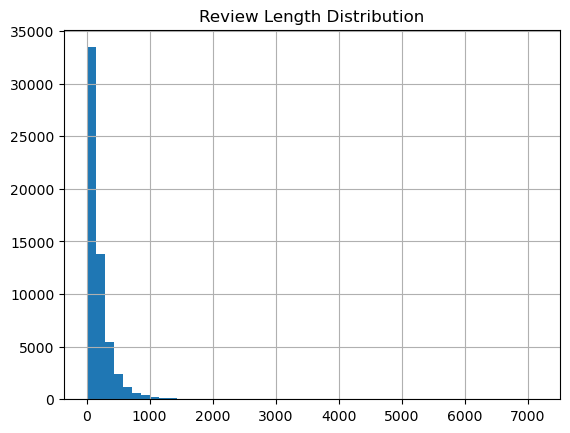

In [48]:
df["review_length"].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

Median of review lengths being 121 words should be a suitable amount for generating a strong signal. However, the abundance of reviews with lower word count (as low as 1 word shown by min) may lead to inconsistent detection later on. Conclusion, these low word count reviews could be filtered to help improve the upcoming model training phase.   

In [49]:
# Filter low word count reviews using a threshold of 20 to allow for short reviews that still contain some meaning 
before = len(df)
df_filtered = df[df["reviewText"].str.len() > 20]
after = len(df_filtered)

print("Removed:", before - after)
print("Remaining:", after)

Removed: 4629
Remaining: 53365


In [50]:
df["inconsistentStatus"].value_counts()

inconsistentStatus
0    37940
1    20054
Name: count, dtype: int64

Data should be more or less similar before filtering, but expecting less inconsistencies during training

Applying Data Text Cleaning

In [51]:
import sys
import os

sys.path.append(os.path.abspath(".."))
print(os.getcwd())

c:\Users\USER\Desktop\FYP\fyp-nlp-reviews\notebooks


In [52]:
import nltk
# nltk.download('stopwords')

In [53]:
from importlib import reload
import src.data.preprocess as p
reload(p)
from src.data.preprocess import preprocess_text

df["clean_text"] = df["reviewText"].apply(preprocess_text)
df[["reviewText", "clean_text"]].head()

,reviewText,clean_text
0,No change in nails at all.,no change in nails at all
1,Garbage! Do not waste your $$$. My nails were worse after using this product for two weeks. Pathetic! Going back to my Vaseline Healthy Hand and and Nails.,garbage do not waste your my nails were worse after using this product for two weeks pathetic going back to my vaseline healthy hand and and nails
2,Nails are still brittle,nails are still brittle
3,Didn’t do any improvement at all.,didn’t do any improvement at all
4,"Helped cuticles, didn't do much for my nails. I gave this product a decent time line, two jars, six months. Nails didn't improve.",helped cuticles didnt do much for my nails i gave this product a decent time line two jars six months nails didnt improve


In [54]:
df.to_csv("../data/processed/cleaned.csv", index=False)

In [55]:
df["clean_text"].sample(5)

39752       i love the elite controllers i love the ability to map the buttons to specific games i love using the paddles on the underside of the controller so i don’t have to take my thumbs off the joysticks
45272                                                                                                                                                cheaply made for the price and small i wouldnt recommend it
19731                                                                                                                    this chromebook so far works great no problem and fast cpu speed i recommend to freinds
6765     i have wanted to try wow for a while i finally bought it and love it the smell is amazing and last for days makes your hair super soft and helps with dandruff the condition feels amazing as well b...
17794    for i didnt expect much but for a laptop to work slower than a cell phone thats just unacceptable when i try to use this laptop the processor straight out 

Normalization phase complete. <br>
Stopword removal was initially considered as part of preprocessing. However, it was excluded from the final pipeline as observations showed that it removed important negation terms (e.g., “no”, “not”), which are crucial for sentiment classification performance. <br>
First model will use Feature Extraction (TF-IDF) and the followinf pipeline:<br>
Raw Text → Normalization → TF-IDF → Model (Logistic Regression / SVM)

For DL Models later on, will be using this pipeline:  <br>
Raw Text → Tokenizer → Padding → Embedding → LSTM/GRU/CNN

TF-IDF

In [56]:
from sklearn.model_selection import train_test_split
from src.features.text_features import get_tfidf_features

In [58]:
X = df["clean_text"]
y = df["sentiment"]  

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
X_train_tfidf, X_test_tfidf, vectorizer = get_tfidf_features(
    X_train, X_test
)

In [60]:
print(X_train_tfidf.shape)
print(y_train.value_counts())

(46395, 5000)
sentiment
0.0    23200
1.0    23195
Name: count, dtype: int64


TF-IDF Model Training<br>
This model will be used for baseline comparison and evaluation tables

Linear Regression

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.879731011294077

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      5800
         1.0       0.89      0.87      0.88      5799

    accuracy                           0.88     11599
   macro avg       0.88      0.88      0.88     11599
weighted avg       0.88      0.88      0.88     11599

Confusion Matrix:
[[5167  633]
 [ 762 5037]]


Naive Bayes

In [74]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

NB Accuracy: 0.8592982153633933

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      5800
         1.0       0.89      0.87      0.88      5799

    accuracy                           0.88     11599
   macro avg       0.88      0.88      0.88     11599
weighted avg       0.88      0.88      0.88     11599

Confusion Matrix:
[[5106  694]
 [ 938 4861]]


SVM

In [76]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8738684369342185

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      5800
         1.0       0.89      0.87      0.88      5799

    accuracy                           0.88     11599
   macro avg       0.88      0.88      0.88     11599
weighted avg       0.88      0.88      0.88     11599

Confusion Matrix:
[[5089  711]
 [ 752 5047]]


Once done with classic ML pipeline as a baseline, proceed to DL pipeline

Deep Learning Model Training <br>
Main focus of the project which will include 3 DL models for evaluation (i.e. LSTM, GRU, CNN) (Goal 1) and improve upon the selected model (HBGRU-LSTM) (Goal 3)

In [109]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


Tokenization

In [110]:
# max_words = 10000
max_words = 20000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# print(X_train_seq[:2])

Padding

In [111]:
# max_len = 200
max_len = 300

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [112]:
print(X_train_pad.shape)

(46395, 300)


LSTM Model

In [113]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

Model Compilation

In [114]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Training

In [116]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 473s 815ms/step - accuracy: 0.9077 - loss: 0.2374 - val_accuracy: 0.8622 - val_loss: 0.3447
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 573s 988ms/step - accuracy: 0.9292 - loss: 0.1922 - val_accuracy: 0.8646 - val_loss: 0.3493
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 546s 941ms/step - accuracy: 0.9164 - loss: 0.2159 - val_accuracy: 0.8597 - val_loss: 0.3966


Model Evaluation

In [117]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

363/363 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.8606 - loss: 0.3527
Test Accuracy: 0.8605914115905762


LSTM model performed poorly. Swapped to BiLSTM expecting an improvement because it can capture context from both directions (past and future), which improves understanding of sentence meaning.

GRU Model

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional

model_gru = Sequential([
    Embedding(input_dim=20000, output_dim=128),

    Bidirectional(GRU(128)),

    Dropout(0.5),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

Training GRU

In [ ]:
model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 438s 737ms/step - accuracy: 0.8152 - loss: 0.4058 - val_accuracy: 0.8615 - val_loss: 0.3327
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 471s 813ms/step - accuracy: 0.8930 - loss: 0.2682 - val_accuracy: 0.8698 - val_loss: 0.3088
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 484s 835ms/step - accuracy: 0.9203 - loss: 0.2061 - val_accuracy: 0.8627 - val_loss: 0.3339
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 480s 828ms/step - accuracy: 0.9380 - loss: 0.1666 - val_accuracy: 0.8655 - val_loss: 0.3914


In [ ]:
    loss, accuracy = model_gru.evaluate(X_test_pad, y_test)
    print("GRU Test Accuracy:", accuracy)

363/363 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.8706 - loss: 0.3112
GRU Test Accuracy: 0.8705922961235046


CNN

In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

In [122]:
model_cnn = Sequential([
    Embedding(input_dim=20000, output_dim=128),

    Conv1D(filters=128, kernel_size=5, activation='relu'),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [123]:
model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [124]:
history_cnn = model_cnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 81s 133ms/step - accuracy: 0.7953 - loss: 0.4256 - val_accuracy: 0.8563 - val_loss: 0.3290
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.8856 - loss: 0.2838 - val_accuracy: 0.8683 - val_loss: 0.3180
